Imports necessários, leitura das imagens de teste que serão usadas e funções básicas.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv2

def normalizar_imagem(img):
    if (img.max()<=1):
        img *= 255
    img = img.astype(np.uint8)
    return img

#Linha a ser trocada para teste é abaixo
img_teste = normalizar_imagem(plt.imread('houses.pgm'))

def escolha_imagem(original):
    opcao = int(input("1 - Imagem de teste original\n2 - Imagem de teste escolhida\n"))
    img = None
    if opcao == 1:
        img = original.copy()
    elif opcao == 2:
        img = img_teste.copy()
    else:
        print("Opção inválida, imagem original usada")
        img = original.copy()

    return img

def plotar_imagem(img,img_modificada, tituloum, titulodois):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    im1 = ax[0].imshow(img, cmap='gray')
    ax[0].set_title(tituloum)

    im2 = ax[1].imshow(img_modificada, cmap='magma')
    ax[1].set_title(titulodois)

    plt.show()


def plotar_histograma(hist_angular):
    num_bins = len(hist_angular)
    indices_bins = np.arange(num_bins)
    
    plt.figure(figsize=(8, 5))
    plt.bar(indices_bins, hist_angular, width=1.0, color='royalblue', edgecolor='black')
    
    plt.xlabel('bin angular', fontsize=12)
    plt.ylabel('energia', fontsize=12)
    plt.xticks(np.arange(0, num_bins + 1, 5))
    plt.xlim([-0.5, num_bins - 0.5])
    plt.title('Orientações Dominantes', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def translacao_imagem(img):
    tx = float(input("Digite a translação em x: "))
    ty = float(input("Digite a translação em y: "))
    matriz_translacao = np.float32([[1, 0, tx], [0, 1, ty]])
    img_transladada = cv2.warpAffine(img, matriz_translacao, (img.shape[1], img.shape[0]), borderMode=cv2.BORDER_WRAP)
    return img_transladada

def rotacao_imagem(img):
    angulo = float(input("Digite o ângulo de rotação(0° a 360°): "))
    centro = (img.shape[1] // 2, img.shape[0] // 2)
    matriz_rotacao = cv2.getRotationMatrix2D(centro, angulo, 1.0)
    img_rotacionada = cv2.warpAffine(img, matriz_rotacao, (img.shape[1], img.shape[0]))
    return img_rotacionada

def mudanca_escala_imagem(img):
    escala = float(input("Digite a escala (<1): "))
    
    h, w = img.shape[:2]
    centro_x, centro_y = w // 2, h // 2
    
    matriz_escala = np.float32([
        [escala, 0, centro_x * (1 - escala)],
        [0, escala, centro_y * (1 - escala)]
    ])
    
    img_com_borda = cv2.warpAffine(img, matriz_escala, (w, h))

    nova_largura = int(w * escala)
    nova_altura = int(h * escala)
    
    img_redimensionada = cv2.resize(img, (nova_largura, nova_altura), interpolation=cv2.INTER_LINEAR)
    
    return img_com_borda, img_redimensionada

def transformada_fourier(img):
    dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitude = cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1])
    espectro_log = 20 * np.log(magnitude + 1)
    return magnitude, espectro_log

def histograma_energia_angular(magnitude, num_bins=36):
    h, w = magnitude.shape
    cy, cx = h // 2, w // 2
    
    Y, X = np.indices((h, w))
    
    dy = Y - cy
    dx = X - cx
    
    # Isso aqui pega o ângulo de cada pixel em relação ao centro da imagem, 
    # usando a função atan2 que retorna o ângulo em radianos.
    angulos_rad = np.arctan2(dy, dx)
    
    # Converte para graus [-180, 180] para facilitar a criação dos bins e leitura
    angulos_graus = np.rad2deg(angulos_rad)
    
    hist, bin_edges = np.histogram(angulos_graus, bins=num_bins, range=(-180, 180), weights=magnitude)
    
    return hist, bin_edges

def salvar_imagem(espectro, nome_arquivo, mapa_cor='magma'):
    plt.imsave(nome_arquivo, espectro, cmap=mapa_cor)

In [5]:
cameraman = normalizar_imagem(plt.imread('cameraman.pgm'))
houses = normalizar_imagem(plt.imread('houses.pgm'))
trucks = normalizar_imagem(plt.imread('trucks.pgm'))

salvar_imagem(cameraman, 'cameraman_salva.png', mapa_cor='gray')
salvar_imagem(houses, 'houses_salva.png', mapa_cor='gray')
salvar_imagem(trucks, 'trucks_salva.png', mapa_cor='gray')

# **Teste de Imagem escolhida**

**Inclui rotação, translação, mudança de escala e também histograma angular de energia.**

Erro máximo entre o espectro original e transladado: 0.00104


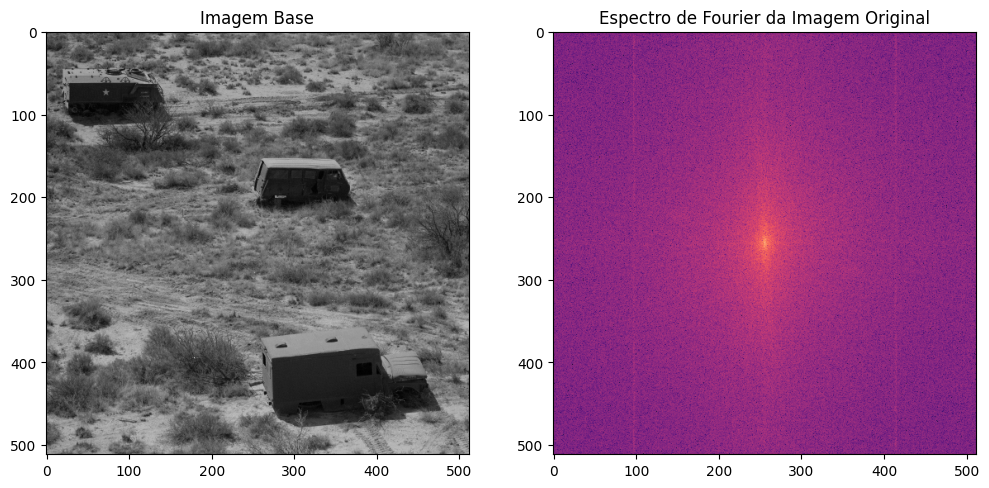

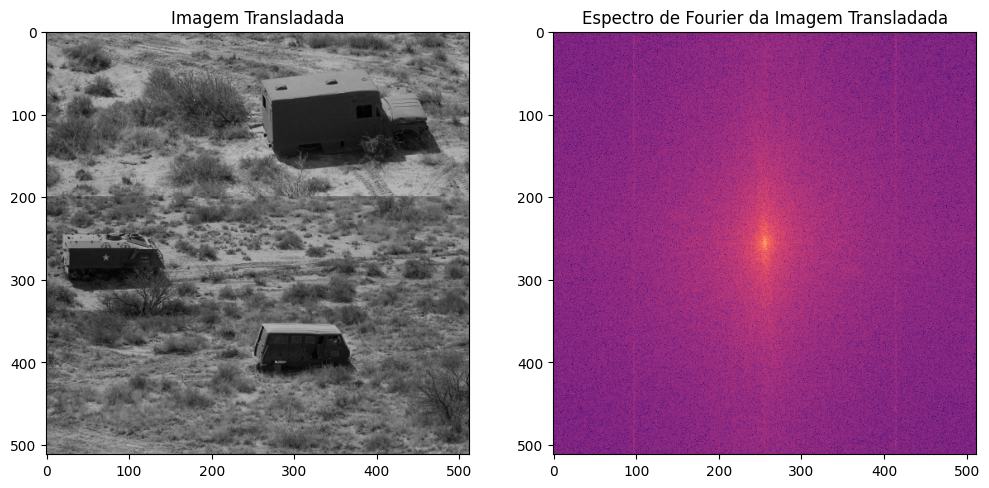

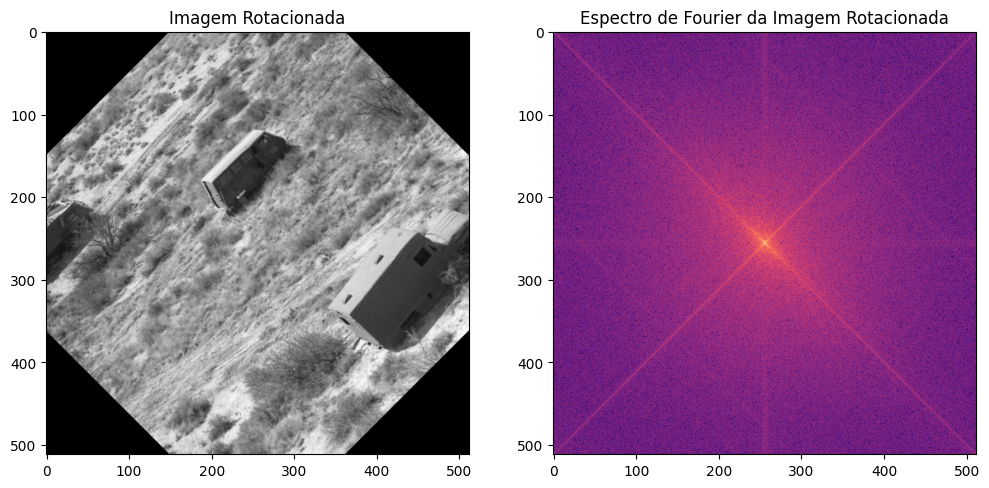

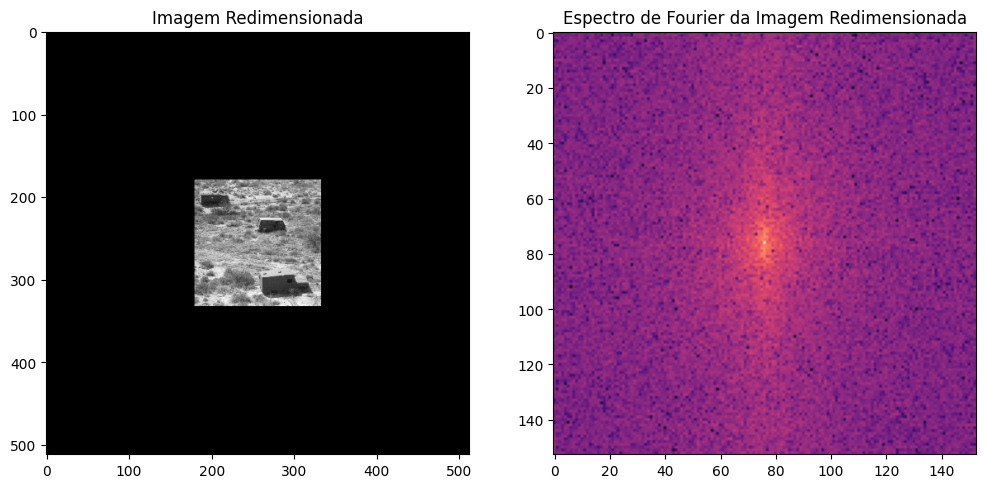

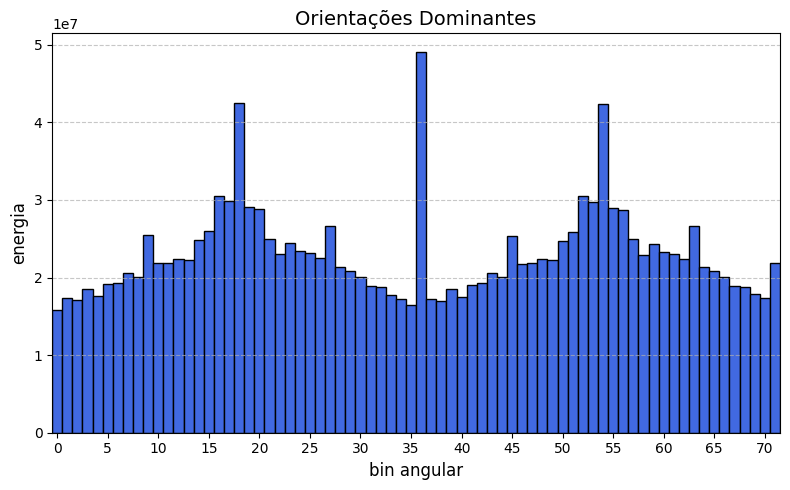

In [51]:
img = escolha_imagem(trucks)

# Espectro original
magnitude, espectro_log = transformada_fourier(img)
histograma, bin_edges = histograma_energia_angular(magnitude, num_bins=72)

# Espectro Transladado
img_transladada = translacao_imagem(img)
magnitudeT, espectro_logT = transformada_fourier(img_transladada)
# histogramaT, bin_edges = histograma_energia_angular(magnitude)

# Comparação entre os espectros original e transladado
diferenca = cv2.absdiff(espectro_log, espectro_logT)
erro_maximo = np.max(diferenca)
print(f"Erro máximo entre o espectro original e transladado: {erro_maximo:.5f}")

# Espectro Rotacionado
img_rotacionada = rotacao_imagem(img)
magnitudeR, espectro_logR = transformada_fourier(img_rotacionada)
# histogramaR, bin_edges = histograma_energia_angular(magnitude)

# Espectro Redimensionado
img_com_borda, img_redimensionada = mudanca_escala_imagem(img)
magnitudeE, espectro_logE = transformada_fourier(img_redimensionada)
# histograma, bin_edges = histograma_energia_angular(magnitude)

# Se quiser salvar a imagem basta descomentar as linhas abaixo
# salvar_imagem(espectro_log, 'espectro_original.png')
# salvar_imagem(espectro_logT, 'espectro_transladada.png')
# salvar_imagem(espectro_logR, 'espectro_rotacionada.png')
# salvar_imagem(espectro_logE, 'espectro_redimensionada.png')

# Plotar as imagens
plotar_imagem(img, espectro_log, "Imagem Base", "Espectro de Fourier da Imagem Original")
plotar_imagem(img_transladada, espectro_logT, "Imagem Transladada", "Espectro de Fourier da Imagem Transladada")
plotar_imagem(img_rotacionada, espectro_logR, "Imagem Rotacionada", "Espectro de Fourier da Imagem Rotacionada")
plotar_imagem(img_com_borda, espectro_logE, "Imagem Redimensionada", "Espectro de Fourier da Imagem Redimensionada")
plotar_histograma(histograma)


**Somente rotação**

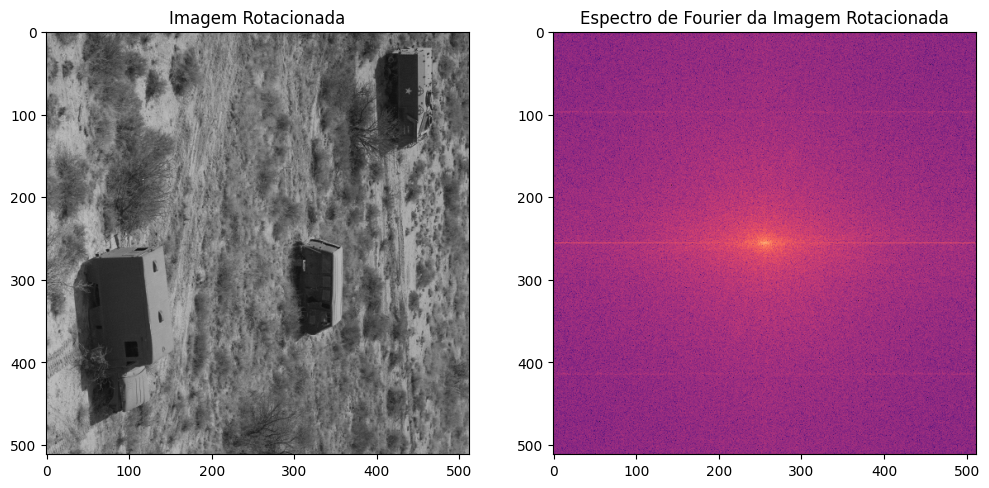

In [55]:
img = escolha_imagem(trucks)

# Espectro Rotacionado
img_rotacionada = rotacao_imagem(img)
magnitudeR, espectro_logR = transformada_fourier(img_rotacionada)
# histogramaR, bin_edges = histograma_energia_angular(magnitude)

# Se quiser salvar a imagem basta descomentar as linha abaixo
# salvar_imagem(espectro_logR, 'espectro_rotacionada.png')

plotar_imagem(img_rotacionada, espectro_logR, "Imagem Rotacionada", "Espectro de Fourier da Imagem Rotacionada")
# plotar_histograma(histograma)


**Somente translação**

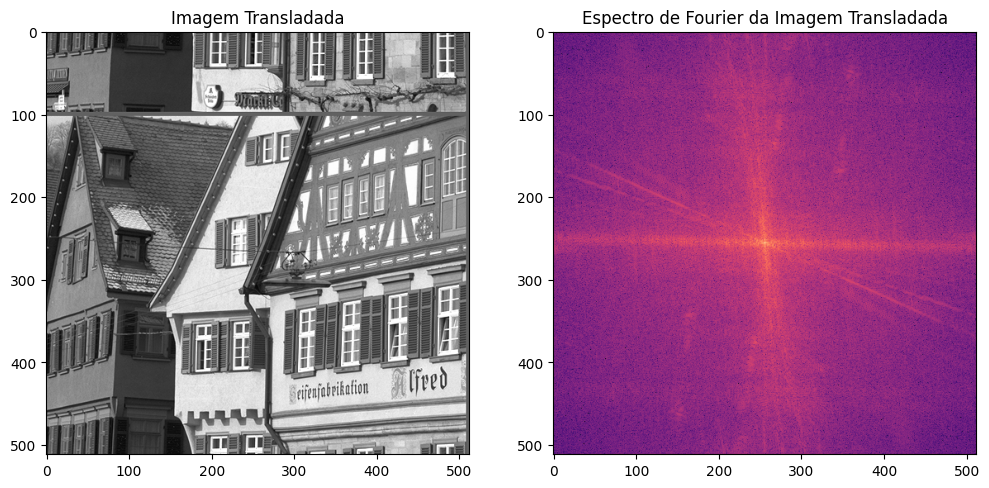

In [ ]:
img = escolha_imagem(trucks)

# Espectro Transladado
img_transladada = translacao_imagem(img)
magnitudeT, espectro_logT = transformada_fourier(img_transladada)


# Se quiser salvar a imagem basta descomentar as linha abaixo
# salvar_imagem(espectro_logT, 'espectro_transladada.png')

plotar_imagem(img_transladada, espectro_logT, "Imagem Transladada", "Espectro de Fourier da Imagem Transladada")
# plotar_histograma(histograma)


**Somente redimensionamento**

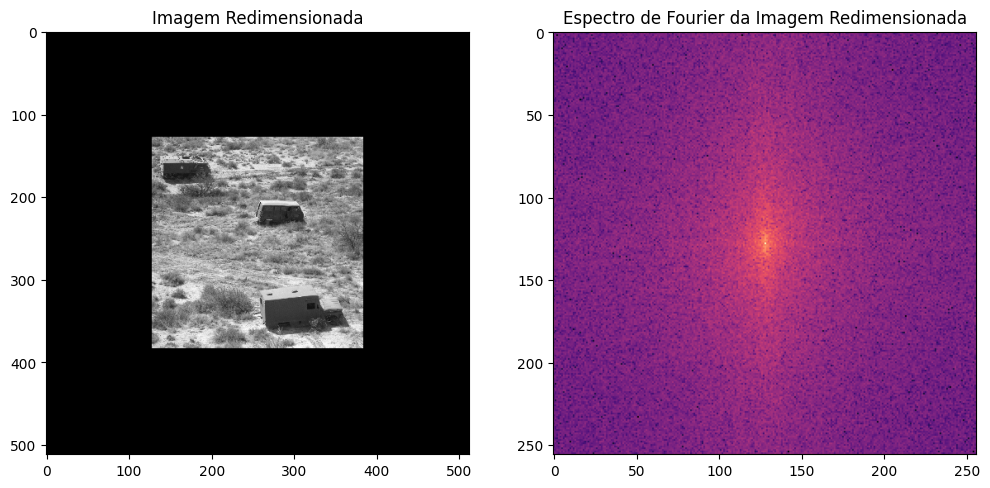

In [56]:
img = escolha_imagem(trucks)

# Espectro Redimensionado
img_com_borda, img_redimensionada = mudanca_escala_imagem(img)
magnitudeE, espectro_logE = transformada_fourier(img_redimensionada)
# histograma, bin_edges = histograma_energia_angular(magnitude)

# Se quiser salvar a imagem basta descomentar as linha abaixo
# salvar_imagem(espectro_logE, 'espectro_redimensionada.png')

plotar_imagem(img_com_borda, espectro_logE, "Imagem Redimensionada", "Espectro de Fourier da Imagem Redimensionada")
# plotar_histograma(histograma)
